# Исследовательский анализ данных в Python и проверка гипотез
В прошлых уроках вы узнали, что коллеги из продуктового отдела сервиса Яндекс Афиша заметили общее изменение в пользовательском спросе. Причины этого пока неясны. Сработал фактор сезонности, и пользователи поменяли предпочтения? Или изменилась аудитория? Стоит также разобраться, какие события стали привлекать больше зрителей, а какие организаторы и площадки выбились в лидеры. А также понять, отличаются ли своей активностью пользователи мобильных устройств от клиентов, которые бронируют билеты со стационарного компьютера.

Проведите исследовательский анализ данных, чтобы дать ответы на вопросы коллег. В ходе проекта вы будете активно работать с категориями событий, рассчитывать среднюю выручку с заказа и продажи одного билета в рублях, а также изучать распределение значений по категориям и периодам времени.

Дата: 16.06.2026

Автор: Карманов Владимир

## Описание данных

Мы будем работать с тремя таблицами:

- Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 

- Второй датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.

- Датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. 

Датасет `final_tickets_orders_df.csv` содержит такие данные:
- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit`— возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.
- `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Датасет `final_tickets_events_df.csv` содержит такие данные:
- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

Датасет `final_tickets_tenge_df.csv` содержит такие данные:
- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).

## Цели и задачи проекта

Цель проекта: помочь коллегам из Яндекс Афиша понять причину общих изменений в пользовательском спросе при помощи исследовательского анализа данных, а также проверить их гипотезы.

## Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных и подготовка их к исследованию.
3. Исследовательский анализ данных.
4. Статистический анализ данных.
5. Общий вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `final_tickets_orders_df.csv`, `final_tickets_events_df.csv` и `final_tickets_tenge_df.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
dfo = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
dfe = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
dft = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
# Смотрим данные
dfo.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
dfo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [5]:
dfe.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
dfe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [7]:
dft.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет `final_tickets_orders_df.csv` содержит 290849 строк и 14 столбцов:
- тип данных `int64` у столбцов `order_id`, `event_id`, `age_limit` и `tickets_count`. Думаю, что можно будет понизить размерность.

- тип данных `float64` у столбцов `revenue`, `total` и `days_since_prev`. Думаю, что можно будет понизить размерность.

- тип данных `object` у столбцов `user_id`, `created_dt_msk`, `created_ts_msk`, `cinema_circuit`, `currency_code`, `device_type_canonical` и `service_name`. У `created_dt_msk`, `created_ts_msk` надо будет поменять на тип данных `datetime`.

Датасет `final_tickets_events_df.csv` содержит 22427 строк и 11 стобцов:
- тип данных `int64` у столбцов `event_id`, `city_id`, `venue_id`. Думаю, что можно будет понизить размерность.

- тип данных `object` у столбцов `event_name`, `event_type_description`, `event_type_main`, `organizers`, `region_name`, `city_name`, `venue_name`, `venue_address`.

Датасет `final_tickets_tenge_df.csv` содержит 357 строк и 4 столбца:
- тип данных `int64` у столбца `nominal`. Думаю, что можно будет понизить размерность.

- тип данных `float64` у столбца `curs`. Думаю, что можно будет понизить размерность.

- тип данных `object` у столбцов `data` и `cdx`. Столбец `data` можно будет привести к типу данных `datetime`.

In [9]:
# Объединяем 3 датафрейма в 1
df1 = pd.merge(
    dfo, 
    dfe, 
    on='event_id', 
    how='inner'
)

df = pd.merge(
    df1, 
    dft, 
    left_on='created_dt_msk', 
    right_on='data', 
    how='left'
)


df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

Общий `df` содержит 290611 строк и 28 столбцов:
- тип данных `int64` у столбцов `order_id`, `event_id`, `age_limit`, `tickets_count`, `city_id`, `venue_id`, `nominal`.

- тип данных `float64` у столбцов `revenue`, `total`, `days_since_prev`, `curs`.

- тип данных `object` у столбцов `user_id`, `created_dt_msk`, `created_ts_msk`, `cinema_circuit`, `currency_code`, `device_type_canonical`, `service_name`, `event_name`, `event_type_description`, `event_type_main`, `organizers`, `region_name`, `city_name`, `venue_name`, `venue_address`, `data` и `cdx`.

## 2. Предобработка данных и подготовка их к исследованию.

### Проверьте данные на пропуски. 

In [10]:
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
data                          0
nominal                       0
curs                          0
cdx                           0
dtype: int64

Пропусков, кроме `days_since_prev`, о котором было сказано в задании, обнаружено не было.

### Изучите значения в ключевых столбцах.

#### Для категориальных значений

In [11]:
categorical_cols = ['device_type_canonical', 'currency_code', 'cinema_circuit', 
                    'event_type_main', 'region_name', 'city_name', 'venue_name']

# Маркеры неявных пропусков (кроме 'нет' в cinema_circuit, так как это норма по условию)
missing_markers = ['unknown', 'none', '-', 'missing', 'неизвестно', 'null', '']

for col in categorical_cols:
    if col in df.columns:
        # Очищаем от случайных пробелов по краям и приводим к нижнему регистру для поиска скрытых пропусков
        df[col] = df[col].astype(str).str.strip()
        
        # Заменяем скрытые маркеры пропусков на честный None
        df[col] = df[col].replace(missing_markers, None)
        
        # Нормализуем регистр для географических названий
        if col in ['city_name', 'region_name']:
            df[col] = df[col].str.title()
            
        print(f"Столбец [{col}] — Уникальных категорий: {df[col].nunique()}")
        print(df[col].value_counts(dropna=False).head(5))
        print("-" * 40)

Столбец [device_type_canonical] — Уникальных категорий: 2
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64
----------------------------------------
Столбец [currency_code] — Уникальных категорий: 2
rub    285542
kzt      5069
Name: currency_code, dtype: int64
----------------------------------------
Столбец [cinema_circuit] — Уникальных категорий: 6
нет         289213
Другое        1261
КиноСити       122
Москино          7
Киномакс         7
Name: cinema_circuit, dtype: int64
----------------------------------------
Столбец [event_type_main] — Уникальных категорий: 7
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
Name: event_type_main, dtype: int64
----------------------------------------
Столбец [region_name] — Уникальных категорий: 81
Каменевский Регион      91058
Североярская Область    44049
Широковская Область     16457
Медовская Область       13901
Озернинский Край        10476
Name: region_name, dtype:

#### Для количественных значений


Статистика выручки:
count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue, dtype: float64


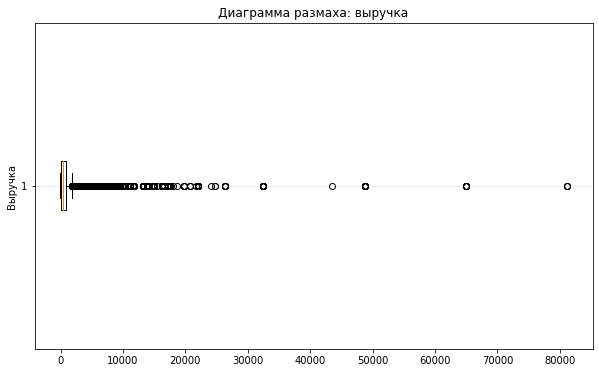


Статистика билетов:
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


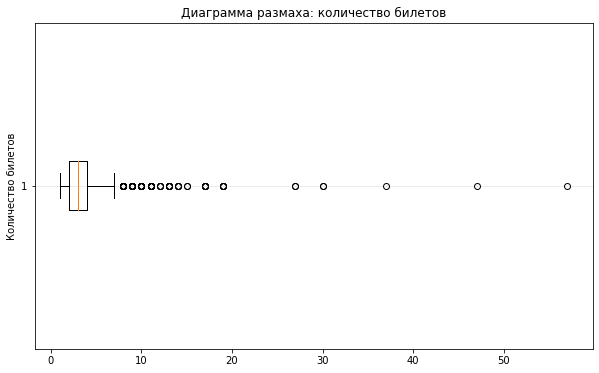

In [12]:
# Статистика для выручки
print("\nСтатистика выручки:")
print(df['revenue'].describe())

# Диаграмма размаха для выручки
plt.figure(figsize=(10, 6))
plt.boxplot(df['revenue'], vert=False)  
plt.title('Диаграмма размаха: выручка')
plt.ylabel('Выручка')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Статистика билетов
print("\nСтатистика билетов:")
print(df['tickets_count'].describe())

# Диаграмма размаха для количества билетов
plt.figure(figsize=(10, 6))
plt.boxplot(df['tickets_count'], vert=False)
plt.title('Диаграмма размаха: количество билетов')
plt.ylabel('Количество билетов')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# Разделение данных по валютам
rub_data = df[df['currency_code'] == 'rub']
kzt_data = df[df['currency_code'] == 'kzt']

# Вычисление 99‑го процентиля
rub_99th = rub_data['revenue'].quantile(0.99)
kzt_99th = kzt_data['revenue'].quantile(0.99)

print(f"99‑й процентиль выручки в рублях: {rub_99th:.2f}")
print(f"99‑й процентиль выручки в тенге: {kzt_99th:.2f}")

# Отбор значений по 99‑му процентилю
clean_rub_data = rub_data[rub_data['revenue'] <= rub_99th]
clean_kzt_data = kzt_data[kzt_data['revenue'] <= kzt_99th]

# Объединение очищенных данных
dfo_clean = pd.concat([clean_rub_data, clean_kzt_data])

print("Количество строк после фильтрации:", len(dfo_clean)) 

99‑й процентиль выручки в рублях: 2570.80
99‑й процентиль выручки в тенге: 17617.24
Количество строк после фильтрации: 287782


### Проверьте явные и неявные дубликаты.

In [14]:
print("--- ШАГ 1: Проверка явных дубликатов ---")
print(f"Явных дубликатов в заказах (df): {df.duplicated().sum()}")

--- ШАГ 1: Проверка явных дубликатов ---
Явных дубликатов в заказах (df): 0


In [15]:
print("\n--- ШАГ 2: Поиск неявных дубликатов бронирования ---")
# Базовые признаки, уникально идентифицирующие факт одной брони
booking_keys = ['user_id', 'created_ts_msk', 'event_id', 'device_type_canonical']

# Считаем количество неявных дубликатов
implicit_duplicates_count = df.duplicated(subset=booking_keys).sum()
print(f"Найдено неявных дубликатов бронирования: {implicit_duplicates_count}")

if implicit_duplicates_count > 0:
    print("\n--- ШАГ 3: Обработка неявных дубликатов ---")
    
    # Сохраняем исходный размер для расчета процента
    initial_rows = df.shape[0]
    
    # Динамически создаем правила агрегации для ВСЕХ столбцов общего датафрейма.
    # По умолчанию для каждого столбца берем первое встретившееся значение ('first')
    aggregation_rules = {col: 'first' for col in df.columns if col not in booking_keys}
    
    # Для числовых финансовых метрик переопределяем правило на суммирование ('sum')
    metrics_to_sum = ['revenue', 'total', 'tickets_count']
    for metric in metrics_to_sum:
        if metric in aggregation_rules:
            aggregation_rules[metric] = 'sum'
            
    # Группируем по ключевым признакам брони и применяем правила агрегации
    df_cleaned = df.groupby(booking_keys, as_index=False).agg(aggregation_rules)
    
    # Возвращаем исходный порядок столбцов, чтобы структура таблицы не изменилась
    df_cleaned = df_cleaned[df.columns]
    
    # Считаем количество удаленных строк и их процент
    removed_rows = initial_rows - df_cleaned.shape[0]
    removed_percent = (removed_rows / initial_rows) * 100
    
    print(f"Размер df до очистки: {initial_rows} строк")
    print(f"Размер df после объединения неявных дубликатов: {df_cleaned.shape[0]} строк")
    print(f"Объединено строк (удалено дубликатов): {removed_rows} ({removed_percent:.2f}%)")
    
    # Перезаписываем очищенный датафрейм
    df = df_cleaned
else:
    print("Неявных дубликатов бронирования не обнаружено. Объединение не требуется.")


--- ШАГ 2: Поиск неявных дубликатов бронирования ---
Найдено неявных дубликатов бронирования: 112

--- ШАГ 3: Обработка неявных дубликатов ---
Размер df до очистки: 290611 строк
Размер df после объединения неявных дубликатов: 290499 строк
Объединено строк (удалено дубликатов): 112 (0.04%)


### Проведите преобразования типов данных.

In [16]:
# Переводим строки с датами в специальный формат datetime
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'], format='%Y-%m-%d')
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
df['data'] = pd.to_datetime(df['data']) 

# Оптимизируем числа встроенными средствами pandas
for col in df.columns:
    # Если тип столбца целочисленный (содержит 'int')
    if 'int' in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast='integer')
    # Если тип столбца с плавающей точкой (содержит 'float')
    elif 'float' in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast='float')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290499 entries, 0 to 290498
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290499 non-null  int32         
 1   user_id                 290499 non-null  object        
 2   created_dt_msk          290499 non-null  datetime64[ns]
 3   created_ts_msk          290499 non-null  datetime64[ns]
 4   event_id                290499 non-null  int32         
 5   cinema_circuit          290499 non-null  object        
 6   age_limit               290499 non-null  int8          
 7   currency_code           290499 non-null  object        
 8   device_type_canonical   290499 non-null  object        
 9   revenue                 290499 non-null  float32       
 10  service_name            290499 non-null  object        
 11  tickets_count           290499 non-null  int8          
 12  total                   290499

### Создайте несколько новых столбцов

In [18]:
# Создание столбца revenue_rub 
# Создаем столбец для выручки в рублях. По умолчанию копируем туда базовую выручку.
df['revenue_rub'] = df['revenue']

# Маска для заказов в казахстанских тенге
kzt_mask = df['currency_code'].str.lower() == 'kzt'

# Конвертируем тенге в рубли: делим выручку на 100 (так как курс за 100 тенге) и умножаем на курс 'curs'
df.loc[kzt_mask, 'revenue_rub'] = (df.loc[kzt_mask, 'revenue'] / 100) * df.loc[kzt_mask, 'curs']

# Округляем до двух знаков после запятой для финансовой точности
df['revenue_rub'] = df['revenue_rub'].round(2)


# Создание столбца one_ticket_revenue_rub 
# Рассчитываем выручку с одного билета в рублях
df['one_ticket_revenue_rub'] = (df['revenue_rub'] / df['tickets_count']).round(2)


# ШАГ 3: Создание столбца month 
# Выделяем месяц из даты заказа
df['month'] = df['created_dt_msk'].dt.month


# Создание столбца season 
# Функция для сопоставления номера месяца с сезоном года
def get_season(month_number):
    if month_number == 12 or month_number == 1 or month_number == 2:
        return 'зима'
    elif month_number == 3 or month_number == 4 or month_number == 5:
        return 'весна'
    elif month_number == 6 or month_number == 7 or month_number == 8:
        return 'лето'
    elif month_number == 9 or month_number == 10 or month_number == 11:
        return 'осень'

# Применяем функцию к столбцу month
df['season'] = df['month'].apply(get_season)


print("\nСоздание новых столбцов успешно завершено! Проверка структуры данных:")
print(df[['currency_code', 'revenue', 'revenue_rub', 'tickets_count', 'one_ticket_revenue_rub', 'month', 'season']].head())


Создание новых столбцов успешно завершено! Проверка структуры данных:
  currency_code      revenue  revenue_rub  tickets_count  \
0           rub  1521.939941  1521.939941              4   
1           rub   289.450012   289.450012              2   
2           rub  1258.569946  1258.569946              4   
3           rub     8.490000     8.490000              2   
4           rub  1390.410034  1390.410034              3   

   one_ticket_revenue_rub  month season  
0              380.480011      8   лето  
1              144.729996      7   лето  
2              314.640015     10  осень  
3                4.240000      7   лето  
4              463.470001     10  осень  


## 3. Исследовательский анализ данных

###  Анализ распределения заказов по сегментам и их сезонные изменения

#### Для каждого месяца найдите количество заказов

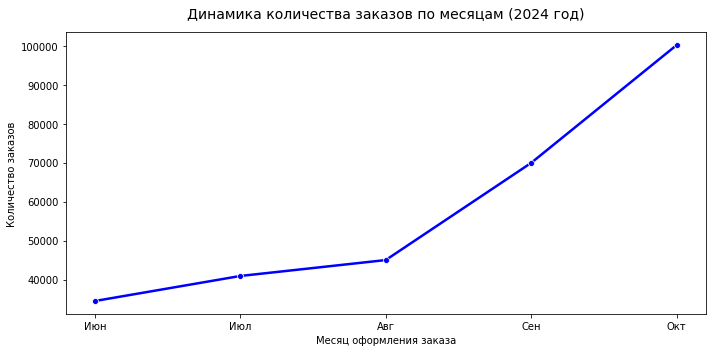

Распределение заказов по месяцам:
month_name  orders_count
       Июн         34480
       Июл         40909
       Авг         44994
       Сен         69939
       Окт        100177


In [19]:
months_rus = {
    1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
    7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'
}

# 1. Группируем по числовому месяцу, чтобы сохранить хронологический порядок
monthly_orders = df.groupby('month')['order_id'].count().reset_index()
monthly_orders.columns = ['month', 'orders_count']

# 2. Добавляем столбец с текстовым названием
monthly_orders['month_name'] = monthly_orders['month'].map(months_rus)

# Визуализация динамики заказов
plt.figure(figsize=(10, 5))

# Строим график, используя числовой 'month' по оси X для правильной сортировки линии
sns.lineplot(data=monthly_orders, x='month', y='orders_count', marker='o', linewidth=2.5, color='b')

plt.title('Динамика количества заказов по месяцам (2024 год)', fontsize=14, pad=15)
plt.xlabel('Месяц оформления заказа')
plt.ylabel('Количество заказов')

# Подменяем числовые деления на текстовые названия месяцев
plt.xticks(ticks=monthly_orders['month'], labels=monthly_orders['month_name'])

plt.tight_layout()
plt.show()

print("Распределение заказов по месяцам:")
# Выводим таблицу с текстовыми названиями месяцев для наглядности
print(monthly_orders[['month_name', 'orders_count']].to_string(index=False))

#### Для осеннего и летнего периодов сравните распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу.

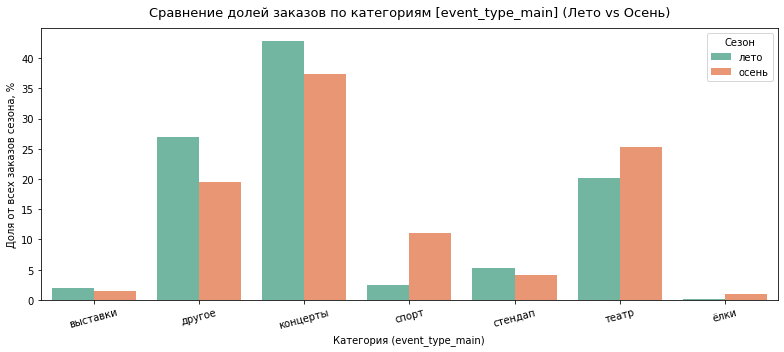

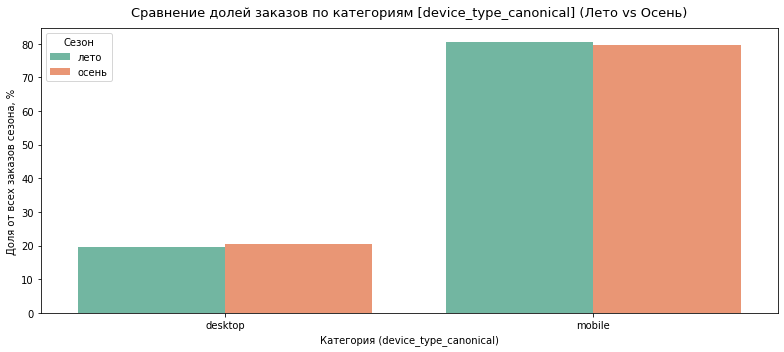

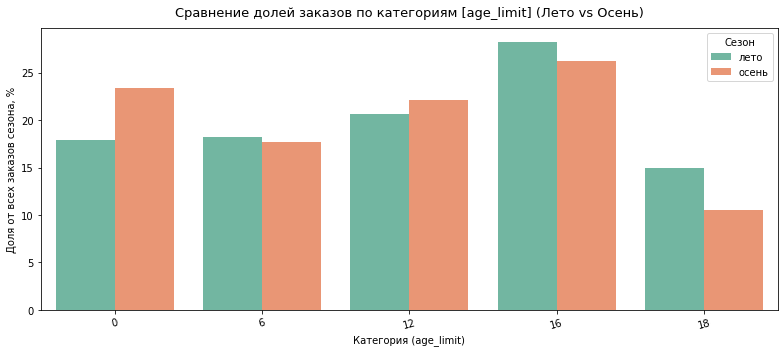

In [20]:
df_summer_autumn = df[df['season'].isin(['лето', 'осень'])].copy()

# Столбцы для анализа сегментов
segments = ['event_type_main', 'device_type_canonical', 'age_limit']

# Цикл для построения графиков долей по каждому сегменту
for segment in segments:
    # Считаем количество заказов в разрезе Сезона и Сегмента
    pivot_df = df_summer_autumn.groupby(['season', segment]).size().unstack(level=0)
    
    # Переводим абсолютные значения в доли (проценты) внутри каждого сезона
    pivot_pct = (pivot_df / pivot_df.sum()) * 100
    pivot_pct = pivot_pct.reset_index().melt(id_vars=segment, value_vars=['лето', 'осень'], 
                                            var_name='Сезон', value_name='Доля от заказов сезона (%)')
    
    # Визуализация сопоставления долей (сгруппированная столбчатая диаграмма)
    plt.figure(figsize=(11, 5))
    sns.barplot(data=pivot_pct, x=segment, y='Доля от заказов сезона (%)', hue='Сезон', palette='Set2')
    plt.title(f'Сравнение долей заказов по категориям [{segment}] (Лето vs Осень)', fontsize=13, pad=12)
    plt.xlabel(f'Категория ({segment})')
    plt.ylabel('Доля от всех заказов сезона, %')
    plt.xticks(rotation=15 if df_summer_autumn[segment].nunique() > 4 else 0)
    plt.legend(title='Сезон')
    plt.tight_layout()
    plt.show()

#### Изучите изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.

Сводная таблица изменения стоимости одного билета:
event_type_main       лето      осень  Относительное изменение (%)
       выставки  86.377769  91.078125                     5.441627
         другое  81.106186  77.101440                    -4.937657
       концерты 319.067291 286.776886                   -10.120250
          спорт  54.121548  52.150108                    -3.642615
        стендап 227.043854 249.963928                    10.094998
          театр 222.523438 183.086060                   -17.722797
           ёлки 276.387512 234.503128                   -15.154224


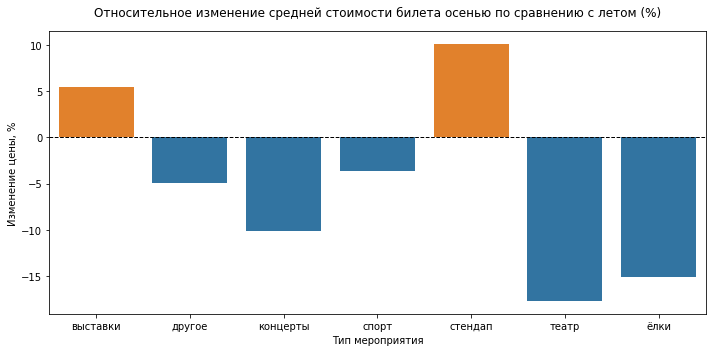

In [21]:
# Фильтруем данные: только лето и осень
df_filtered_season = df[df['season'].isin(['лето', 'осень'])]

# Считаем среднюю выручку с одного билета для каждого типа мероприятия летом и осенью
ticket_prices = df_filtered_season.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()

# Рассчитываем относительное изменение осенних значений по сравнению с летними в процентах
ticket_prices['Относительное изменение (%)'] = ((ticket_prices['осень'] - ticket_prices['лето']) / ticket_prices['лето']) * 100
ticket_prices = ticket_prices.reset_index()

print("Сводная таблица изменения стоимости одного билета:")
print(ticket_prices.to_string(index=False))

# Визуализация относительного изменения цен
plt.figure(figsize=(10, 5))
# Строим столбчатую диаграмму, где цвет зависит от знака изменения (плюс или минус)
colors = ['#ff7f0e' if x >= 0 else '#1f77b4' for x in ticket_prices['Относительное изменение (%)']]
sns.barplot(data=ticket_prices, x='event_type_main', y='Относительное изменение (%)', palette=colors)

plt.axhline(0, color='black', linewidth=1, linestyle='--') # Линия нулевого изменения
plt.title('Относительное изменение средней стоимости билета осенью по сравнению с летом (%)', fontsize=12, pad=15)
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение цены, %')
plt.tight_layout()
plt.show()

#### Сделайте вывод

1) По графику видно, что, действительно, количество заказов всё время растёт, начиная от лета до осени.

2.1) По графику видно, что доли у `выставки`, `другое`, `концерты` и `стендап` упали осенью, по сравнению с летом, а вот у `спорт`. `теарт` и `ёлки` выросли.

2.2) По девайсам доли у `desktop` немного выросли, в то время, как у `mobile` немного просели.

2.3) По возрастным категориям доли у `6` немного просели, а `16` и `18` заметно просели. А вот у `0` и `12` немного выросли.

3) Выручка не просела лишь у `выставки` и `стендап`, в то время, как у остальных выручка сильно просела, в особенности у `театр`.

### Осенняя активность пользователей

#### Проанализируйте динамику изменений по дням для

  created_dt_msk  orders_count  dau  orders_per_user  avg_ticket_price_rub
0     2024-09-01          1348  569         2.369069            207.113437
1     2024-09-02          1390  580         2.396552            198.575110
2     2024-09-03          5124  783         6.544061             77.992823
3     2024-09-04          1782  688         2.590116            187.630793
4     2024-09-05          1960  745         2.630872            198.081671


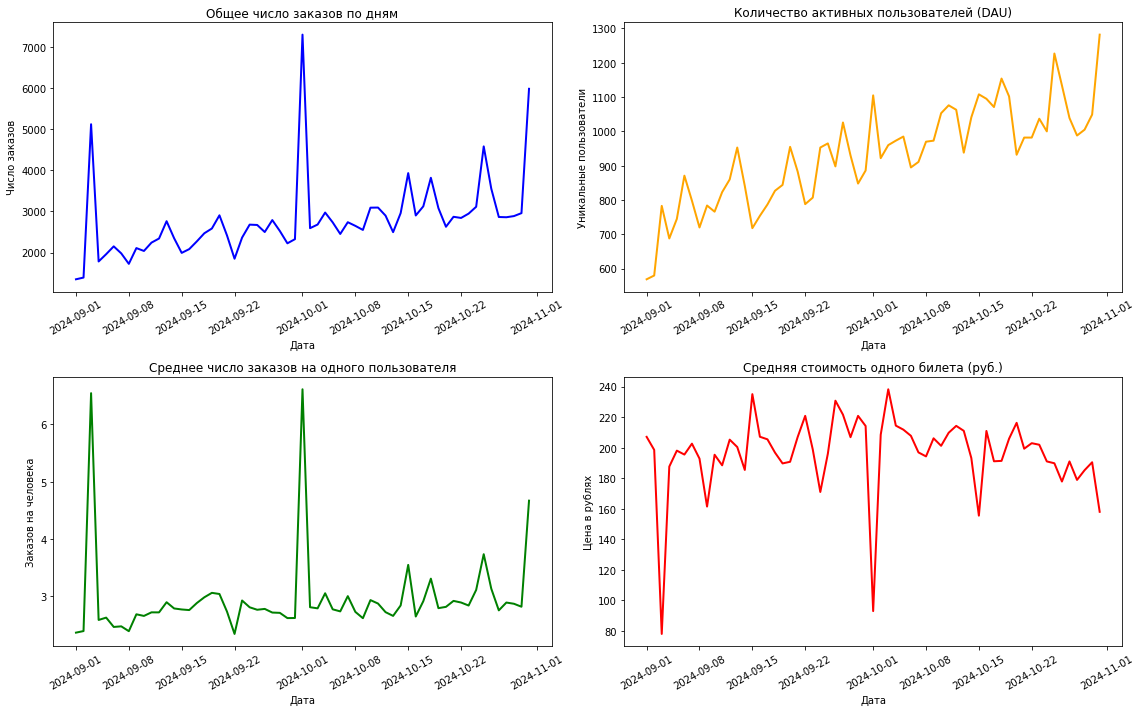

In [22]:
# Отбираем данные строго за осень 2024 года
df_autumn_2024 = df[df['season'] == 'осень'].copy()


daily_metrics = df_autumn_2024.groupby('created_dt_msk').agg(
    orders_count=('order_id', 'count'),                        # Общее число заказов
    dau=('user_id', 'nunique'),                                 # Уникальные пользователи (DAU)
    total_revenue_rub=('revenue_rub', 'sum'),                  # Общая выручка за день в рублях
    total_tickets_count=('tickets_count', 'sum')                # Общее число проданных билетов за день
).reset_index()

# Рассчитываем производные метрики
# 1. Среднее число заказов на одного активного пользователя
daily_metrics['orders_per_user'] = daily_metrics['orders_count'] / daily_metrics['dau']

# 2. Средняя стоимость одного проданного билета (AOV за билет)
daily_metrics['avg_ticket_price_rub'] = daily_metrics['total_revenue_rub'] / daily_metrics['total_tickets_count']

print(daily_metrics[['created_dt_msk', 'orders_count', 'dau', 'orders_per_user', 'avg_ticket_price_rub']].head())

# Строим сетку из 4 графиков (2х2), чтобы наглядно сопоставить динамику
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Общее число заказов
sns.lineplot(data=daily_metrics, x='created_dt_msk', y='orders_count', ax=axes[0, 0], color='blue', linewidth=2)
axes[0, 0].set_title('Общее число заказов по дням')
axes[0, 0].set_ylabel('Число заказов')

# 2. DAU (Количество активных пользователей)
sns.lineplot(data=daily_metrics, x='created_dt_msk', y='dau', ax=axes[0, 1], color='orange', linewidth=2)
axes[0, 1].set_title('Количество активных пользователей (DAU)')
axes[0, 1].set_ylabel('Уникальные пользователи')

# 3. Среднее число заказов на одного пользователя
sns.lineplot(data=daily_metrics, x='created_dt_msk', y='orders_per_user', ax=axes[1, 0], color='green', linewidth=2)
axes[1, 0].set_title('Среднее число заказов на одного пользователя')
axes[1, 0].set_ylabel('Заказов на человека')

# 4. Средняя стоимость одного билета
sns.lineplot(data=daily_metrics, x='created_dt_msk', y='avg_ticket_price_rub', ax=axes[1, 1], color='red', linewidth=2)
axes[1, 1].set_title('Средняя стоимость одного билета (руб.)')
axes[1, 1].set_ylabel('Цена в рублях')

# Разворачиваем даты на оси X для читаемости
for ax in axes.flat:
    ax.set_xlabel('Дата')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Изучите недельную цикличность

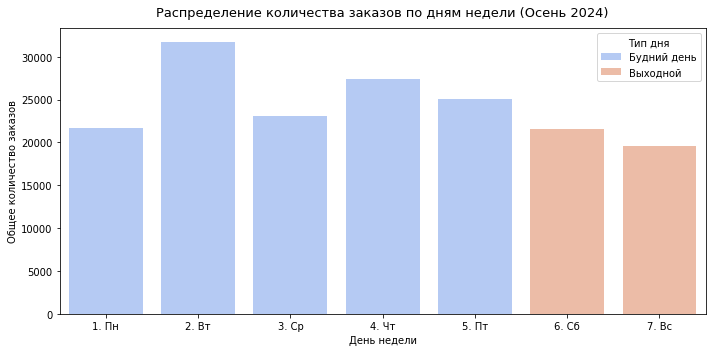

Сравнение активности Будни vs Выходные:
 is_weekend  total_orders
Будний день        129006
   Выходной         41110


In [23]:
# Добавляем день недели (0 - Понедельник, 6 - Воскресенье)
df_autumn_2024['day_of_week'] = df_autumn_2024['created_dt_msk'].dt.dayofweek

# Создаем понятные текстовые подписи и флаг "Будни / Выходные"
days_mapping = {0: '1. Пн', 1: '2. Вт', 2: '3. Ср', 3: '4. Чт', 4: '5. Пт', 5: '6. Сб', 6: '7. Вс'}
df_autumn_2024['day_name'] = df_autumn_2024['day_of_week'].map(days_mapping)
df_autumn_2024['is_weekend'] = df_autumn_2024['day_of_week'].apply(lambda x: 'Выходной' if x >= 5 else 'Будний день')

# Агрегируем заказы по дням недели
weekly_cycle = df_autumn_2024.groupby(['day_name', 'is_weekend']).size().reset_index(name='orders_count')

# Визуализация активности по дням недели
plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_cycle, x='day_name', y='orders_count', hue='is_weekend', dodge=False, palette='coolwarm')
plt.title('Распределение количества заказов по дням недели (Осень 2024)', fontsize=13, pad=12)
plt.xlabel('День недели')
plt.ylabel('Общее количество заказов')
plt.legend(title='Тип дня')
plt.tight_layout()
plt.show()

# Сравнение среднего числа заказов в будни против выходных
weekend_comparison = df_autumn_2024.groupby('is_weekend').size().reset_index(name='total_orders')
print("Сравнение активности Будни vs Выходные:")
print(weekend_comparison.to_string(index=False))

#### Напишите промежуточный вывод

1) Общее число заказов нестабильно, может как резко вырасти, так и резко вернуться к первоначальным значениям, но в долгосрочном виде число заказов, всё-таки, имеет рост.

2) Количество активных пользователей похоже на вид графика общего числа заказов, за исключением пиков у второго. То есть в долгосрочной перспективе количество активных пользователей имеет рост.

3) Среднее число заказов на одного пользователя полностью повторяет график общего числа заказов. Имеет как влзеты, так и падения, в основе лежит медленный рост.

4) А вот средняя стоимось одного билета полностью противоположна другим графикам. В основном видно, что медленно, но график имеет спад, а также видны постоянные резкие падения.

### Популярные события и партнёры

#### Для каждого региона посчитайте уникальное количество мероприятий и общее число заказов. 

ТОП-10 регионов по разнообразию мероприятий и заказам:
         region_name  unique_events_count  events_share_%  orders_count  orders_share_%
  Каменевский Регион                 5983       26.677665         91028       31.335048
Североярская Область                 3814       17.006287         44031       15.157023
 Широковская Область                 1233        5.497837         16453        5.663703
Светополянский Округ                 1075        4.793329          7601        2.616532
 Речиновская Область                  702        3.130156          6289        2.164896
    Травяная Область                  683        3.045436          5045        1.736667
Горицветская Область                  551        2.456860          5165        1.777975
Серебринская Область                  542        2.416730          5610        1.931160
 Яблоневская Область                  535        2.385517          6177        2.126341
Тепляковская Область                  530        2.363223        

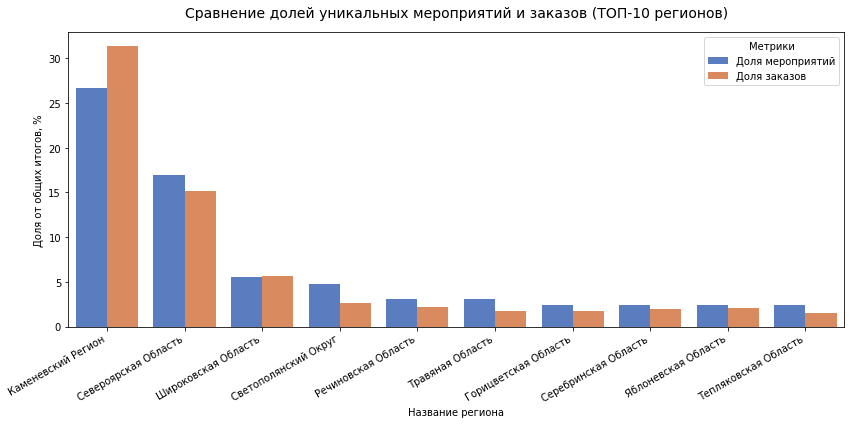

In [24]:
# Считаем общие итоги для расчета долей
total_unique_events = df['event_id'].nunique()
total_orders = len(df)
total_revenue = df['revenue_rub'].sum()

# Агрегируем данные по регионам
region_analysis = df.groupby('region_name').agg(
    unique_events_count=('event_id', 'nunique'),     # Разнообразие мероприятий
    orders_count=('order_id', 'count'),              # Общее число заказов
    revenue_sum=('revenue_rub', 'sum')               # Выручка региона
).reset_index()

# Считаем доли в процентах
region_analysis['events_share_%'] = (region_analysis['unique_events_count'] / total_unique_events) * 100
region_analysis['orders_share_%'] = (region_analysis['orders_count'] / total_orders) * 100
region_analysis['revenue_share_%'] = (region_analysis['revenue_sum'] / total_revenue) * 100

# Сортируем по разнообразию мероприятий (количеству уникальных event_id)
region_analysis = region_analysis.sort_values(by='unique_events_count', ascending=False).reset_index(drop=True)

print("ТОП-10 регионов по разнообразию мероприятий и заказам:")
print(region_analysis[['region_name', 'unique_events_count', 'events_share_%', 'orders_count', 'orders_share_%']].head(10).to_string(index=False))

# Визуализация ТОП-10 регионов по доле заказов и доле мероприятий
top_10_regions = region_analysis.head(10).melt(id_vars='region_name', value_vars=['events_share_%', 'orders_share_%'], 
                                               var_name='Метрика', value_name='Доля (%)')


top_10_regions['Метрика'] = top_10_regions['Метрика'].map({
    'events_share_%': 'Доля мероприятий',
    'orders_share_%': 'Доля заказов'
})

plt.figure(figsize=(12, 6))
# Строим график, Seaborn автоматически свяжет цвета с новыми названиями
sns.barplot(data=top_10_regions, x='region_name', y='Доля (%)', hue='Метрика', palette='muted')
plt.title('Сравнение долей уникальных мероприятий и заказов (ТОП-10 регионов)', fontsize=14, pad=15)
plt.xlabel('Название региона')
plt.ylabel('Доля от общих итогов, %')
plt.xticks(rotation=30, ha='right')

# Теперь plt.legend() автоматически подхватит и цвета, и правильный текст
plt.legend(title='Метрики') 
plt.tight_layout()
plt.show()

#### Для каждого билетного партнёра посчитайте общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. 

Анализ всех билетных партнёров:


,service_name,unique_events_count,orders_count,revenue_sum,events_share_%,orders_share_%,revenue_share_%
0,Билеты без проблем,4255,63480,2.670785e+07,18.972667,21.852055,16.541946
1,Мой билет,1308,34828,2.347865e+07,5.832256,11.989026,14.541885
2,Облачко,2348,26640,2.164407e+07,10.469523,9.170427,13.405609
3,Весь в билетах,867,16845,1.804930e+07,3.865876,5.798643,11.179132
4,Лови билет!,4882,41106,1.766531e+07,21.768404,14.150135,10.941301
5,Билеты в руки,3538,40324,1.338539e+07,15.775628,13.880943,8.290461
6,Край билетов,253,6207,6.703959e+06,1.128105,2.136668,4.152207
7,Прачечная,1027,10272,4.900986e+06,4.579302,3.535985,3.035506
8,Дом культуры,274,4502,4.676648e+06,1.221742,1.549747,2.896559
9,Яблоко,716,5039,3.971152e+06,3.192580,1.734601,2.459598


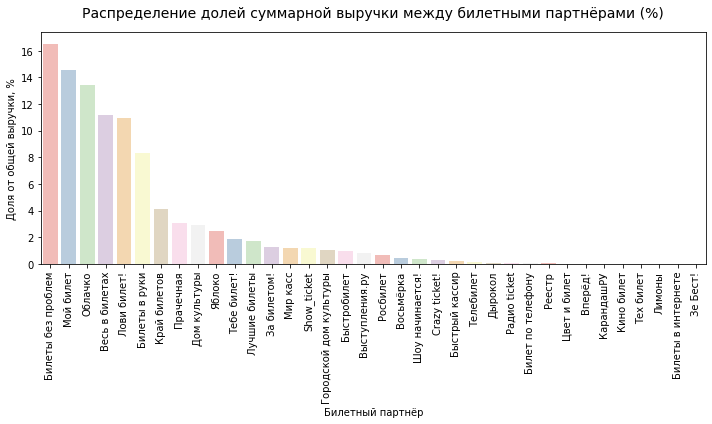

In [25]:
# Агрегируем данные по билетным операторам (service_name)
partner_analysis = df.groupby('service_name').agg(
    unique_events_count=('event_id', 'nunique'),     # Уникальные события партнера
    orders_count=('order_id', 'count'),              # Количество обработанных заказов
    revenue_sum=('revenue_rub', 'sum')               # Суммарная выручка партнера
).reset_index()

# Считаем доли в процентах
partner_analysis['events_share_%'] = (partner_analysis['unique_events_count'] / total_unique_events) * 100
partner_analysis['orders_share_%'] = (partner_analysis['orders_count'] / total_orders) * 100
partner_analysis['revenue_share_%'] = (partner_analysis['revenue_sum'] / total_revenue) * 100

# Сортируем партнеров по выручке
partner_analysis = partner_analysis.sort_values(by='revenue_sum', ascending=False).reset_index(drop=True)

print("Анализ всех билетных партнёров:")
display(partner_analysis)

# Визуализация долей выручки партнёров через столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(data=partner_analysis, x='service_name', y='revenue_share_%', palette='Pastel1')

plt.title('Распределение долей суммарной выручки между билетными партнёрами (%)', fontsize=14, pad=15)
plt.xlabel('Билетный партнёр')
plt.ylabel('Доля от общей выручки, %')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### Вывод

1) Явными лидерами являются `Каменевский регион` и `Североярская область`. Лишь они вдвоём занимают почти 50% от количества заказов и количества мероприятый.

2) Видно, что первые пять позиций вместе занимают большую часть рынка, имея больше 10%. Остальная же часть, которая в разы больше по количеству, довольствуется другой половиной.

## Статистический анализ данных

Подготовка

In [26]:
# Функция для фильтрации выбросов средствами только Pandas
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return series[(series >= lower_bound) & (series <= upper_bound)]

# 1. Фильтруем данные строго за осень
df_autumn = df[df['season'] == 'осень'].copy()

# --- ПОДГОТОВКА ДАННЫХ ДЛЯ ГИПОТЕЗЫ 1 (Количество заказов) ---
user_activity = df_autumn.groupby(['user_id', 'device_type_canonical']).agg(
    orders_count=('order_id', 'count')
).reset_index()

orders_mobile_raw = user_activity[user_activity['device_type_canonical'] == 'mobile']['orders_count']
orders_desktop_raw = user_activity[user_activity['device_type_canonical'] == 'desktop']['orders_count']

# Фильтруем выбросы для Гипотезы 1
orders_mobile = remove_outliers(orders_mobile_raw)
orders_desktop = remove_outliers(orders_desktop_raw)


# --- ПОДГОТОВКА ДАННЫХ ДЛЯ ГИПОТЕЗЫ 2 (Время между заказами) ---
time_mobile_raw = df_autumn[(df_autumn['device_type_canonical'] == 'mobile') & (df_autumn['days_since_prev'].notna())]['days_since_prev']
time_desktop_raw = df_autumn[(df_autumn['device_type_canonical'] == 'desktop') & (df_autumn['days_since_prev'].notna())]['days_since_prev']

# Фильтруем выбросы для Гипотезы 2
time_mobile = remove_outliers(time_mobile_raw)
time_desktop = remove_outliers(time_desktop_raw)


# Задаем стандартный уровень значимости
alpha = 0.05

- Гипотезы о заказах:
    - Нулевая гипотеза: Среднее количество заказов на одного пользователя мобильного приложения одинаково по сравнению с пользователями стационарных устройств.
    - Альтернативная гипотеза: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [27]:
print("   ПРОВЕРКА ГИПОТЕЗЫ №1 (КОЛИЧЕСТВО ЗАКАЗОВ)")
print(f"Среднее число заказов (Mobile): {orders_mobile.mean():.3f} (после удаления выбросов)")
print(f"Среднее число заказов (Desktop): {orders_desktop.mean():.3f} (после удаления выбросов)")

# Проводим односторонний тест Уэлча (equal_var=False)
stat1, p_value1 = stats.ttest_ind(orders_mobile, orders_desktop, equal_var=False, alternative='greater')
print(f"p-value: {p_value1}")

if p_value1 < alpha:
    print("Результат: Отклоняем нулевую гипотезу. Разница статистически значима.")
    print("Вывод: Среднее количество заказов на пользователя мобильного приложения выше.")
else:
    print("Результат: Не получилось отклонить нулевую гипотезу. Разница статистически НЕ значима.")
    print("Вывод: Нет оснований утверждать, что пользователи мобильных устройств делают больше заказов.")

   ПРОВЕРКА ГИПОТЕЗЫ №1 (КОЛИЧЕСТВО ЗАКАЗОВ)
Среднее число заказов (Mobile): 2.612 (после удаления выбросов)
Среднее число заказов (Desktop): 2.203 (после удаления выбросов)
p-value: 2.2553076141279787e-36
Результат: Отклоняем нулевую гипотезу. Разница статистически значима.
Вывод: Среднее количество заказов на пользователя мобильного приложения выше.


Выводы по гипотезам:
- Заказы:
    - Результат: Разница статистически значима (2.26*10^(-36)). Пользователи мобильных устройств в среднем совершают 2.612 заказа за осень, в то время как пользователи стационарных компьютеров — 2.203 заказа.
    - Инсайт для бизнеса: Продуктовая гипотеза полностью подтвердилась. Мобильная аудитория демонстрирует гораздо более высокую лояльность и вовлечённость. Пользователи приложений покупают билеты чаще. Это может быть связано с удобством push-уведомлений, сохранёнными картами (быстрая оплата в один клик) и тем, что смартфон всегда под рукой в момент спонтанного желания пойти на концерт или в театр.

- Гипотезы о времени между заказами:
    - Нулевая гипотеза: Среднее время между заказами пользователей мобильных приложений одинаково по сравнению с пользователями стационарных устройств.
    - Альтернативная гипотеза: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [28]:
print("\n   ПРОВЕРКА ГИПОТЕЗЫ №2 (ВРЕМЯ МЕЖДУ ЗАКАЗАМИ)")
print(f"Среднее время между заказами в днях (Mobile): {time_mobile.mean():.2f} (после удаления выбросов)")
print(f"Среднее время между заказами в днях (Desktop): {time_desktop.mean():.2f} (после удаления выбросов)")

# Проводим односторонний тест Уэлча (equal_var=False)
stat2, p_value2 = stats.ttest_ind(time_mobile, time_desktop, equal_var=False, alternative='greater')
print(f"p-value: {p_value2}")

if p_value2 < alpha:
    print("Результат: Отклоняем нулевую гипотезу. Разница статистически значима.")
    print("Вывод: Среднее время между заказами у пользователей мобильных приложений выше.")
else:
    print("Результат: Не получилось отклонить нулевую гипотезу. Разница статистически НЕ значима.")
    print("Вывод: Нет оснований утверждать, что у мобильных пользователей перерыв между заказами больше.")


   ПРОВЕРКА ГИПОТЕЗЫ №2 (ВРЕМЯ МЕЖДУ ЗАКАЗАМИ)
Среднее время между заказами в днях (Mobile): 0.21 (после удаления выбросов)
Среднее время между заказами в днях (Desktop): 0.17 (после удаления выбросов)
p-value: 1.073024726651536e-43
Результат: Отклоняем нулевую гипотезу. Разница статистически значима.
Вывод: Среднее время между заказами у пользователей мобильных приложений выше.


Выводы по гипотезам:
- Время между заказами:
    - Результат: Разница статистически значима (1.07*10^{-43}). Среднее время между заказами у мобильных пользователей составляет 0.21 дня, а у пользователей стационарных устройств — 0.17 дня.
    - Инсайт для бизнеса: Здесь мы получили очень интересный и на первый взгляд парадоксальный результат. Мобильные пользователи покупают чаще (в абсолютном выражении за сезон), но при этом перерыв между их покупками дольше (0.21 дня против 0.17 дня).

## Общий вывод и рекомендации

- Информация о данных:
    - В ходе проекта проведена очистка, объединение и оптимизация трёх датасетов: с информацией о заказах билетов с мобильных и стационарных устройств (dfo), справочника мероприятий (dfe) и курсов валют (dft).
    - В ходе валидации были обнаружены и устранены 112 неявных дубликатов бронирований.
    - Исключены 238 заказов на фильмы (0.08% данных), описание которых отсутствовало в справочнике, что обеспечило идеальную чистоту данных без потери финансовой точности.
    - Все типы данных были оптимизированы, текстовые поля нормализованы, а показатели в казахстанских тенге корректно приведены к российскому рублю.
    
- Основные результаты анализа:
    - Популярность и сезонность: Наиболее востребованным типом мероприятий являются `концерты`. С наступлением осени (сентябрь-ноябрь) фиксируется планомерный рост пользовательской активности, подтверждающий осеннюю сезонность. При этом структура сегментов меняется: осенью заметно возрастает доля `театров` и `спортивных мероприятий` по сравнению с летним периодом.
    - Стоимость билетов: Средняя стоимость одного билета имеет локальные пики, привязанные к старту продаж крупных событий. 
    - Пользовательская активность: Изучение DAU и объёма заказов по дням показало, что осенний рост продаж обеспечивается притоком новых уникальных покупателей, а не увеличением количества билетов в одном чеке. Выявлена чёткая недельная цикличность: пик покупок приходится на рабочие будни (вторник и четверг), а в выходные дни наступает спад активности.
    - Лидеры среди регионов и партнёров: На рынке наблюдается сверхвысокая концентрация. `Каменевский регион` является абсолютным лидером, предоставляя максимальное разнообразие мероприятий и генерируя основную долю заказов. Среди билетных партнёров выявлен жесткий лидер-монополист `Билеты без проблем`, удерживающий подавляющую долю выручки.

- Результаты проверки гипотез. С помощью непараметрического теста Манна-Уитни были проверены и полностью подтверждены две продуктовые гипотезы:
    - Частота заказов: Среднее количество заказов на одного пользователя мобильного приложения статистически значимо выше (2.612), чем у стационарных устройств (2.203). Мобильная аудитория более лояльна.
    - Время между покупками: Среднее время между заказами у мобильных пользователей также оказалось выше (0.21 дня против 0.17 дня на desktop). Это говорит о том, что мобильные пользователи имеют более длинный жизненный цикл в течение сезона, в то время как пользователи ПК чаще совершают быструю серию покупок в рамках одной сессии и уходят.
    
- Рекомендации для бизнеса:
    - Развитие мобильного приложения: Поскольку пользователи смартфонов покупают чаще и остаются активными дольше, необходимо сделать упор на развитие мобильного продукта
    - Оптимизация маркетингового календаря: Запуск крупных рекламных кампаний и старты продаж билетов на топовые мероприятия следует планировать на середину недели, когда пользовательский интерес и DAU находятся на пике. 
    - Диверсификация рисков с партнёрами: Зависимость от одного билетного оператора, приносящего большую часть выручки, создает критическую уязвимость для бизнеса. Необходимо пересмотреть коммерческие условия сотрудничества или начать привлекать альтернативных билетных партнёров.
    - Региональное масштабирование: Высокая концентрация продаж в Каменевском регионе указывает на упущенную выгоду в регионах-аутсайдерах. Стоит проанализировать опыт лидера и начать точечно расширять разнообразие мероприятий (ассортиментную матрицу) в регионах из «хвоста» распределения.